SVM Classification for Machine-Generated Text Detection
Dataset: Balanced Merged 4-Language (MULTITuDE + MultiSocial)
Languages: English, German, Czech, Spanish
Task: Binary Classification (Human vs Machine)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import joblib

warnings.filterwarnings('ignore')
sns.set_palette("husl")

# Random seed
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

In [ ]:
# Loading the balanced dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/OurBalancedDataset.csv')
print(f"Dataset loaded!")
print(f"Total samples: {len(df):,}")
print(f"Columns: {df.columns.tolist()}")

# Verify balance
print(f"\nDataset Verification:")
print(f"Languages: {df['language'].value_counts().to_dict()}")
print(f"Binary labels: {df['binary_label'].value_counts().to_dict()}")
print(f"Sources: {df['dataset_source'].value_counts().to_dict()}")
print(f"\nSample rows:")
print(df[['text', 'binary_label', 'language', 'dataset_source']].head(5))

Dataset loaded!
Total samples: 26,671
Columns: ['text', 'label', 'multi_label', 'language', 'dataset_source', 'binary_label', 'char_length']

Dataset Verification:
Languages: {'es': 6668, 'de': 6668, 'cs': 6668, 'en': 6667}
Binary labels: {'machine': 13336, 'human': 13335}
Sources: {'MultiSocial': 14804, 'MULTITuDE': 11867}

Sample rows:
                                                text binary_label language  \
0  El jueves pasado, 28 de abril, el Tribunal Pen...      machine       es   
1  Für McLaren-Mercedes lief es diese Saison bisl...        human       de   
2  Las Vegas: Die gesuchte bzw. evtl bereits gefu...        human       de   
3  El Ministerio de Industria, Energía y Turismo ...        human       es   
4  Na gut, vielleicht läuft er dann mal im Vollra...        human       de   

  dataset_source  
0      MULTITuDE  
1      MULTITuDE  
2    MultiSocial  
3      MULTITuDE  
4    MultiSocial  


In [ ]:
#PREPARING LABELS
# Convert binary_label to numeric (0=human, 1=machine)
df['label_numeric'] = df['binary_label'].map({'human': 0, 'machine': 1})
print("Label mapping:")
print("  human  0")
print("  machine  1")
print(f"\nLabel distribution:")
print(df['label_numeric'].value_counts().sort_index())

# Verify no missing labels
if df['label_numeric'].isnull().sum() > 0:
    print(f"\nWARNING: {df['label_numeric'].isnull().sum()} missing labels")
else:
    print(f"\nAll labels converted successfully")

Label mapping:
  human  0
  machine  1

Label distribution:
label_numeric
0    13335
1    13336
Name: count, dtype: int64

All labels converted successfully


In [ ]:
# Spliting the dataset
# First split: 80% train, 20% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=df[['language', 'label_numeric']]
)

# Second split: 50% val, 50% test (from the 20% temp)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=temp_df[['language', 'label_numeric']]
)

print(f"Split completed:")
print(f" Train: {len(train_df):,} samples ({len(train_df)/len(df)*100:.1f}%)")
print(f" Val:   {len(val_df):,} samples ({len(val_df)/len(df)*100:.1f}%)")
print(f" Test:  {len(test_df):,} samples ({len(test_df)/len(df)*100:.1f}%)")

# Verify stratification
print(f"\nTrain set verification:")
print(f"  Languages: {train_df['language'].value_counts().to_dict()}")
print(f"  Labels: {train_df['label_numeric'].value_counts().to_dict()}")

print(f"\nVal set verification:")
print(f"  Languages: {val_df['language'].value_counts().to_dict()}")
print(f"  Labels: {val_df['label_numeric'].value_counts().to_dict()}")

print(f"\nTest set verification:")
print(f"  Languages: {test_df['language'].value_counts().to_dict()}")
print(f"  Labels: {test_df['label_numeric'].value_counts().to_dict()}")

Split completed:
 Train: 21,336 samples (80.0%)
 Val:   2,667 samples (10.0%)
 Test:  2,668 samples (10.0%)

Train set verification:
  Languages: {'en': 5334, 'cs': 5334, 'de': 5334, 'es': 5334}
  Labels: {1: 10668, 0: 10668}

Val set verification:
  Languages: {'cs': 668, 'es': 667, 'de': 666, 'en': 666}
  Labels: {0: 1334, 1: 1333}

Test set verification:
  Languages: {'de': 668, 'es': 667, 'en': 667, 'cs': 666}
  Labels: {1: 1335, 0: 1333}


In [ ]:
# INITIALIZING TF-IDF VECTORIZER

vectorizer = TfidfVectorizer(
    max_features=10000,          # Top 10k features
    ngram_range=(1, 3),          # Unigrams, bigrams, trigrams
    min_df=2,                    # Ignore terms in < 2 documents
    max_df=0.95,                 # Ignore terms in > 95% documents
    sublinear_tf=True,           # Use log scaling for term frequency
    strip_accents='unicode',     # Remove accents
    lowercase=True,              # Convert to lowercase
    analyzer='word'              # Word-level analysis
)

print("TF-IDF Vectorizer configured:")
print(f"Max features: 10,000")
print(f"N-gram range: (1, 3)")
print(f"Min DF: 2")
print(f"Max DF: 0.95")
print(f"Sublinear TF: True")
print(f"Lowercase: True")

TF-IDF Vectorizer configured:
Max features: 10,000
N-gram range: (1, 3)
Min DF: 2
Max DF: 0.95
Sublinear TF: True
Lowercase: True


In [ ]:
# EXTRACTING TF-IDF FEATURES

# Fit on training data
print("Fitting vectorizer on training data...")
start_time = time.time()

X_train = vectorizer.fit_transform(train_df['text'])
y_train = train_df['label_numeric'].values

fit_time = time.time() - start_time

print(f"Training features extracted in {fit_time:.2f}s")
print(f" Vocabulary size: {len(vectorizer.vocabulary_):,}")
print(f" Feature matrix shape: {X_train.shape}")
print(f" Sparsity: {(1.0 - X_train.nnz / (X_train.shape[0] * X_train.shape[1])) * 100:.2f}%")

# Transform validation data
print("\nTransforming validation data...")
X_val = vectorizer.transform(val_df['text'])
y_val = val_df['label_numeric'].values
print(f"Validation features: {X_val.shape}")

# Transform test data
print("\nTransforming test data...")
X_test = vectorizer.transform(test_df['text'])
y_test = test_df['label_numeric'].values
print(f"Test features: {X_test.shape}")

print(f"\nAll features extracted")

Fitting vectorizer on training data...
Training features extracted in 41.05s
 Vocabulary size: 10,000
 Feature matrix shape: (21336, 10000)
 Sparsity: 99.27%

Transforming validation data...
Validation features: (2667, 10000)

Transforming test data...
Test features: (2668, 10000)

All features extracted


In [ ]:
#Hyperparameter tunning
#GridSearch
param_grid = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],           # Regularization parameter
    'max_iter': [1000, 2000, 5000],                # Maximum iterations
    'class_weight': ['balanced', None],             # Handle class imbalance
    'loss': ['squared_hinge', 'hinge']             # Loss function
}

total_combinations = np.prod([len(v) for v in param_grid.values()])

print(f"\nGrid Search Configuration:")
print(f"Total combinations: {total_combinations}")
print(f"Cross-validation folds: 3")
print(f"Scoring metric: Macro F1")
print(f"\nParameter Grid:")
for param, values in param_grid.items():
    print(f"{param:15s}: {values}")


Grid Search Configuration:
Total combinations: 60
Cross-validation folds: 3
Scoring metric: Macro F1

Parameter Grid:
C              : [0.01, 0.1, 1.0, 10.0, 100.0]
max_iter       : [1000, 2000, 5000]
class_weight   : ['balanced', None]
loss           : ['squared_hinge', 'hinge']


In [ ]:
from sklearn.metrics import make_scorer
base_model = LinearSVC( dual=False, random_state=RANDOM_SEED)
# Use Macro F1 as scoring metric
f1_scorer = make_scorer(f1_score, average='macro')
print(f"\nTraining set size: {X_train.shape[0]:,} samples")
print(f"Feature dimensions: {X_train.shape[1]:,} features")


Training set size: 21,336 samples
Feature dimensions: 10,000 features


In [ ]:
#Starting Grid search
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=3,                          # 3-fold cross-validation
    scoring=f1_scorer,             # Optimize for Macro F1
    n_jobs=-1,                     # Use all CPU cores
    verbose=2,                     # Show progress
    return_train_score=True        # Return training scores for analysis
)

# Fit on training data
grid_search.fit(X_train, y_train)
print("Grid search completed")

print(f"\nBEST HYPERPARAMETERS:")
for param, value in grid_search.best_params_.items():
    print(f"   {param:15s}: {value}")

print(f"\n   Best CV Score (Training): {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 60 candidates, totalling 180 fits
Grid search completed

BEST HYPERPARAMETERS:
   C              : 1.0
   class_weight   : balanced
   loss           : squared_hinge
   max_iter       : 1000

   Best CV Score (Training): 0.9231


In [ ]:
#top 10 hyperparameter combos
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results.sort_values('rank_test_score')
for idx in range(min(10, len(cv_results))):
    row = cv_results.iloc[idx]
    print(f"\nRank {idx + 1}:")
    print(f"   Parameters: {row['params']}")
    print(f"   CV F1 (mean ± std): {row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}")
    print(f"   Train F1: {row['mean_train_score']:.4f}")
    print(f"   Fit time: {row['mean_fit_time']:.2f}s")


Rank 1:
   Parameters: {'C': 1.0, 'class_weight': None, 'loss': 'squared_hinge', 'max_iter': 1000}
   CV F1 (mean ± std): 0.9231 ± 0.0010
   Train F1: 0.9891
   Fit time: 0.55s

Rank 2:
   Parameters: {'C': 1.0, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'max_iter': 2000}
   CV F1 (mean ± std): 0.9231 ± 0.0010
   Train F1: 0.9891
   Fit time: 0.55s

Rank 3:
   Parameters: {'C': 1.0, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'max_iter': 5000}
   CV F1 (mean ± std): 0.9231 ± 0.0010
   Train F1: 0.9891
   Fit time: 0.55s

Rank 4:
   Parameters: {'C': 1.0, 'class_weight': 'balanced', 'loss': 'squared_hinge', 'max_iter': 1000}
   CV F1 (mean ± std): 0.9231 ± 0.0010
   Train F1: 0.9891
   Fit time: 0.57s

Rank 5:
   Parameters: {'C': 1.0, 'class_weight': None, 'loss': 'squared_hinge', 'max_iter': 2000}
   CV F1 (mean ± std): 0.9231 ± 0.0010
   Train F1: 0.9891
   Fit time: 0.52s

Rank 6:
   Parameters: {'C': 1.0, 'class_weight': None, 'loss': 'squared_hinge', 'max_iter'

In [ ]:
#Evaluating on Validation set
best_model = grid_search.best_estimator_

# Predict on validation set
y_val_pred = best_model.predict(X_val)

# Calculate metrics
val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='macro')
val_precision = precision_score(y_val, y_val_pred, average='macro')
val_recall = recall_score(y_val, y_val_pred, average='macro')

print(f"\nTuned Model - Validation Metrics:")
print(f"Accuracy:  {val_acc:.4f}")
print(f"Macro-F1:  {val_f1:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall:    {val_recall:.4f}")

print(f"\nClassification Report:")
print(classification_report(y_val, y_val_pred,target_names=['Human', 'Machine'],digits=4))


Tuned Model - Validation Metrics:
Accuracy:  0.9261
Macro-F1:  0.9261
Precision: 0.9262
Recall:    0.9261

Classification Report:
              precision    recall  f1-score   support

       Human     0.9214    0.9318    0.9266      1334
     Machine     0.9310    0.9205    0.9257      1333

    accuracy                         0.9261      2667
   macro avg     0.9262    0.9261    0.9261      2667
weighted avg     0.9262    0.9261    0.9261      2667



In [ ]:
print("Grid Search Complete")
print(f"\nBest Model Configuration:")
print(f"C: {grid_search.best_params_['C']}")
print(f"max_iter: {grid_search.best_params_['max_iter']}")
print(f"class_weight: {grid_search.best_params_['class_weight']}")
print(f"loss: {grid_search.best_params_['loss']}")

print(f"\nValidation Performance:")
print(f"Macro-F1: {val_f1:.4f}")
print(f"Accuracy: {val_acc:.4f}")


Grid Search Complete

Best Model Configuration:
C: 1.0
max_iter: 1000
class_weight: balanced
loss: squared_hinge

Validation Performance:
Macro-F1: 0.9261
Accuracy: 0.9261


In [ ]:
#TRAINING SVM CLASSIFIER

# Initialize SVM
svm_model = LinearSVC(
    C=grid_search.best_params_['C'],
    max_iter=grid_search.best_params_['max_iter'],
    class_weight=grid_search.best_params_['class_weight'],
    loss=grid_search.best_params_['loss'],
    dual=False,
    random_state=RANDOM_SEED
)

print("SVM Configuration (Tuned):")
print(f"Kernel: Linear")
print(f"C: {grid_search.best_params_['C']}")
print(f"Max iterations: {grid_search.best_params_['max_iter']}")
print(f"Class weight: {grid_search.best_params_['class_weight']}")
print(f"Loss: {grid_search.best_params_['loss']}")

# Train
print(f"\nTraining on {len(y_train):,} samples...")
print(f"Human: {sum(y_train==0):,}")
print(f"Machine: {sum(y_train==1):,}")

start_time = time.time()
svm_model.fit(X_train, y_train)
train_time = time.time() - start_time

print(f"\nTraining completed in {train_time:.2f}s")

SVM Configuration (Tuned):
Kernel: Linear
C: 1.0
Max iterations: 1000
Class weight: balanced
Loss: squared_hinge

Training on 21,336 samples...
Human: 10,668
Machine: 10,668

Training completed in 1.38s


In [ ]:
#TRAINING SET EVALUATION"
y_train_pred = svm_model.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='macro')
train_precision = precision_score(y_train, y_train_pred, average='macro')
train_recall = recall_score(y_train, y_train_pred, average='macro')

print(f"Training Metrics:")
print(f"Accuracy:  {train_acc:.4f}")
print(f"Macro-F1:  {train_f1:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall:    {train_recall:.4f}")

if train_f1 > 0.95:
    print(f"\nExcellent training fit")
elif train_f1 > 0.85:
    print(f"\nGood training fit")
else:
    print(f"\nTraining fit may be insufficient")

Training Metrics:
Accuracy:  0.9844
Macro-F1:  0.9844
Precision: 0.9844
Recall:    0.9844

Excellent training fit


In [ ]:
#VALIDATION SET EVALUATION
y_val_pred = svm_model.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred, average='macro')
val_precision = precision_score(y_val, y_val_pred, average='macro')
val_recall = recall_score(y_val, y_val_pred, average='macro')

print(f"Validation Metrics:")
print(f"Accuracy:  {val_acc:.4f}")
print(f"Macro-F1:  {val_f1:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall:    {val_recall:.4f}")

# Compare to training
print(f"\nTrain vs Val:")
print(f"F1 drop: {(train_f1 - val_f1):.4f} ({(train_f1-val_f1)/train_f1*100:.1f}%)")

if abs(train_f1 - val_f1) < 0.10:
    print(f"Good generalization")
else:
    print(f"Possible overfitting")

Validation Metrics:
Accuracy:  0.9261
Macro-F1:  0.9261
Precision: 0.9262
Recall:    0.9261

Train vs Val:
F1 drop: 0.0583 (5.9%)
Good generalization


In [ ]:
#TEST SET EVALUATION
y_test_pred = svm_model.predict(X_test)
test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='macro')
test_precision = precision_score(y_test, y_test_pred, average='macro')
test_recall = recall_score(y_test, y_test_pred, average='macro')
print(f"Test Metrics:")
print(f"Accuracy:  {test_acc:.4f}")
print(f"Macro-F1:  {test_f1:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred,target_names=['Human', 'Machine'],digits=4))

Test Metrics:
Accuracy:  0.9243
Macro-F1:  0.9243
Precision: 0.9243
Recall:    0.9243

Detailed Classification Report:
              precision    recall  f1-score   support

       Human     0.9249    0.9235    0.9242      1333
     Machine     0.9237    0.9251    0.9244      1335

    accuracy                         0.9243      2668
   macro avg     0.9243    0.9243    0.9243      2668
weighted avg     0.9243    0.9243    0.9243      2668



In [ ]:
#RESULTS SUMMARY
results = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Samples': [len(y_train), len(y_val), len(y_test)],
    'Accuracy': [train_acc, val_acc, test_acc],
    'Macro-F1': [train_f1, val_f1, test_f1],
    'Precision': [train_precision, val_precision, test_precision],
    'Recall': [train_recall, val_recall, test_recall]
})

print(results.to_string(index=False))
print(f"\nKey Metrics:")
print(f"Training Time: {train_time:.2f}s")
print(f"Test Macro-F1: {test_f1:.4f}")
print(f"Vocabulary Size: {len(vectorizer.vocabulary_):,} features")

     Split  Samples  Accuracy  Macro-F1  Precision   Recall
     Train    21336  0.984393  0.984392   0.984445 0.984393
Validation     2667  0.926134  0.926132   0.926190 0.926132
      Test     2668  0.924288  0.924288   0.924289 0.924287

Key Metrics:
Training Time: 1.38s
Test Macro-F1: 0.9243
Vocabulary Size: 10,000 features


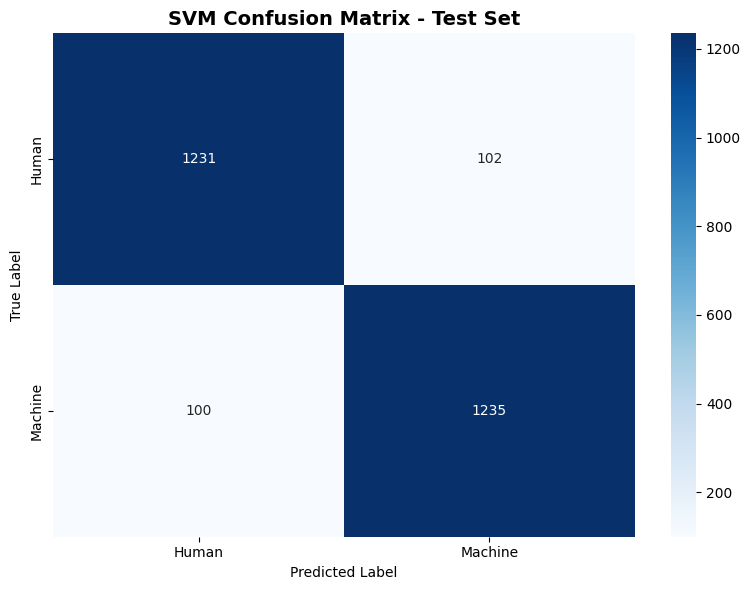

In [ ]:
#CONFUSION MATRIX

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human', 'Machine'],
            yticklabels=['Human', 'Machine'])
plt.title('SVM Confusion Matrix - Test Set', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/svm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# PERFORMANCE BY LANGUAGE (Test Set)
languages = ['cs', 'de', 'en', 'es']
lang_results = []

for lang in languages:
    # Filter test set for this language
    lang_mask = test_df['language'] == lang
    X_lang = X_test[lang_mask.values]
    y_lang = y_test[lang_mask.values]

    if len(y_lang) > 0:
        y_lang_pred = svm_model.predict(X_lang)

        lang_acc = accuracy_score(y_lang, y_lang_pred)
        lang_f1 = f1_score(y_lang, y_lang_pred, average='macro')
        lang_precision = precision_score(y_lang, y_lang_pred, average='macro')
        lang_recall = recall_score(y_lang, y_lang_pred, average='macro')

        lang_results.append({
            'Language': lang.upper(),
            'Samples': len(y_lang),
            'Accuracy': f"{lang_acc:.4f}",
            'Macro-F1': f"{lang_f1:.4f}",
            'Precision': f"{lang_precision:.4f}",
            'Recall': f"{lang_recall:.4f}"
        })

# Create DataFrame
lang_df = pd.DataFrame(lang_results)
print(lang_df.to_string(index=False))

# Average
avg_f1 = np.mean([float(r['Macro-F1']) for r in lang_results])
print(f"\nAverage Macro-F1 across languages: {avg_f1:.4f}")

Language  Samples Accuracy Macro-F1 Precision Recall
      CS      666   0.8904   0.8904    0.8908 0.8904
      DE      668   0.9251   0.9251    0.9252 0.9251
      EN      667   0.9505   0.9505    0.9505 0.9505
      ES      667   0.9310   0.9310    0.9314 0.9310

Average Macro-F1 across languages: 0.9243


In [ ]:
#SAVING MODEL AND RESULTS

# Save the trained model
model_path = '/content/drive/MyDrive/Colab Notebooks/svm_model.pkl'
joblib.dump(svm_model, model_path)
print(f"Model saved: {model_path}")

# Save the vectorizer
vectorizer_path = '/content/drive/MyDrive/Colab Notebooks/svm_vectorizer.pkl'
joblib.dump(vectorizer, vectorizer_path)
print(f"Vectorizer saved: {vectorizer_path}")

# Save results
results_dict = {
    'model': 'SVM (Linear)',
    'dataset': 'Balanced Merged 4-Language',
    'total_samples': len(df),
    'train_samples': len(train_df),
    'val_samples': len(val_df),
    'test_samples': len(test_df),
    'languages': ['en', 'de', 'cs', 'es'],
    'features': {
        'type': 'TF-IDF',
        'max_features': 10000,
        'ngram_range': '(1,3)',
        'vocabulary_size': len(vectorizer.vocabulary_)
    },
    'training_time_seconds': train_time,
    'metrics': {
        'train': {
            'accuracy': float(train_acc),
            'macro_f1': float(train_f1),
            'precision': float(train_precision),
            'recall': float(train_recall)
        },
        'validation': {
            'accuracy': float(val_acc),
            'macro_f1': float(val_f1),
            'precision': float(val_precision),
            'recall': float(val_recall)
        },
        'test': {
            'accuracy': float(test_acc),
            'macro_f1': float(test_f1),
            'precision': float(test_precision),
            'recall': float(test_recall)
        }
    },
    'random_seed': RANDOM_SEED,
    'timestamp': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

import json
results_path = '/content/drive/MyDrive/Colab Notebooks/svm_results.json'
with open(results_path, 'w') as f:
    json.dump(results_dict, f, indent=2)

print(f"Results saved: {results_path}")

print(f"\nTraining Complete")
print(f"Test Macro-F1: {test_f1:.4f}")

Model saved: /content/drive/MyDrive/Colab Notebooks/svm_model.pkl
Vectorizer saved: /content/drive/MyDrive/Colab Notebooks/svm_vectorizer.pkl
Results saved: /content/drive/MyDrive/Colab Notebooks/svm_results.json

Training Complete
Test Macro-F1: 0.9243


In [ ]:
#LOADING CROSS-LINGUAL TEST DATA
# Load original MULTITuDE for unseen languages
df_multitude_full = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/multitude_v3_clean.csv')
CROSSLING_LANGUAGES = ['pt', 'nl', 'ru']

crossling_data = {}
for lang in CROSSLING_LANGUAGES:
    lang_df = df_multitude_full[df_multitude_full['language'] == lang].copy()

    # Create binary label
    lang_df['binary_label'] = lang_df['multi_label'].apply(
        lambda x: 'human' if str(x).lower() == 'human' else 'machine'
    )
    lang_df['label_numeric'] = lang_df['binary_label'].map({'human': 0, 'machine': 1})

    crossling_data[lang] = lang_df

    print(f"{lang.upper()}: {len(lang_df):,} samples")
    print(f"  Human: {sum(lang_df['label_numeric']==0):,}")
    print(f"  Machine: {sum(lang_df['label_numeric']==1):,}")

print(f"\nCross lingual test data loaded for: {CROSSLING_LANGUAGES}")

PT: 10,344 samples
  Human: 1,299
  Machine: 9,045
NL: 10,344 samples
  Human: 1,299
  Machine: 9,045
RU: 10,327 samples
  Human: 1,300
  Machine: 9,027

Cross lingual test data loaded for: ['pt', 'nl', 'ru']


In [ ]:
#CROSS-LINGUAL EVALUATION (Unseen Languages)
crossling_results = []

for lang in CROSSLING_LANGUAGES:
    print(f"\nEvaluating on {lang.upper()}...")

    # Transform features
    X_crossling = vectorizer.transform(crossling_data[lang]['text'])
    y_crossling = crossling_data[lang]['label_numeric'].values

    # Predict
    y_crossling_pred = svm_model.predict(X_crossling)

    # Metrics
    crossling_acc = accuracy_score(y_crossling, y_crossling_pred)
    crossling_f1 = f1_score(y_crossling, y_crossling_pred, average='macro')
    crossling_precision = precision_score(y_crossling, y_crossling_pred, average='macro')
    crossling_recall = recall_score(y_crossling, y_crossling_pred, average='macro')

    crossling_results.append({
        'Language': lang.upper(),
        'Samples': len(y_crossling),
        'Accuracy': f"{crossling_acc:.4f}",
        'Macro-F1': f"{crossling_f1:.4f}",
        'Precision': f"{crossling_precision:.4f}",
        'Recall': f"{crossling_recall:.4f}"
    })

    print(f"  {lang.upper()}: F1={crossling_f1:.4f}, Acc={crossling_acc:.4f}")

# Summary
crossling_df = pd.DataFrame(crossling_results)
print(f"\nCross-Lingual Results:")
print(crossling_df.to_string(index=False))

avg_crossling_f1 = np.mean([float(r['Macro-F1']) for r in crossling_results])
print(f"\nAverage Cross-Lingual F1: {avg_crossling_f1:.4f}")
print(f"Test F1 (seen): {test_f1:.4f}")
print(f"Performance drop: {(test_f1 - avg_crossling_f1):.4f} ({(test_f1-avg_crossling_f1)/test_f1*100:.1f}%)")


Evaluating on PT...
  PT: F1=0.2372, Acc=0.2372

Evaluating on NL...
  NL: F1=0.1655, Acc=0.1706

Evaluating on RU...
  RU: F1=0.1939, Acc=0.1962

Cross-Lingual Results:
Language  Samples Accuracy Macro-F1 Precision Recall
      PT    10344   0.2372   0.2372    0.5585 0.5549
      NL    10344   0.1706   0.1655    0.5531 0.5218
      RU    10327   0.1962   0.1939    0.5606 0.5369

Average Cross-Lingual F1: 0.1989
Test F1 (seen): 0.9243
Performance drop: 0.7254 (78.5%)
